Random Vectors
NumPy solution:
Slope: -0.2219972345805921, Intercept: 0.3958961317853336
Residuals: [ 0.20444632 -0.04200819 -0.20968252 -0.13731375  0.18455814]
Largest residual error: 0.20968252230683382 @ (0.4983123536029691, 0.0755896450212945)
Smallest residual error: 0.04200819173660114 @ (0.1502920879755414, 0.32052351213881924)

My custom solution:
Slope: -0.2219972345805919, Intercept: 0.39589613178533345
Residuals: [ 0.20444632 -0.04200819 -0.20968252 -0.13731375  0.18455814]
Largest residual error: 0.20968252230683376 @ (0.4983123536029691, 0.0755896450212945)
Smallest residual error: 0.042008191736600975 @ (0.1502920879755414, 0.32052351213881924)

Linear Function with Error
NumPy solution:
Slope: 2.5417816217932185, Intercept: 0.745041778801696
Residuals: [-0.26362883  1.02449349 -0.56970855 -0.28503927  0.69403088  0.78109538
 -0.88870669 -0.47684964 -0.46186217  0.81459172  0.66470625 -0.03258305
 -0.65628689 -0.1486643  -0.06546887  0.54543456  0.50080858 -0.36628781
 -

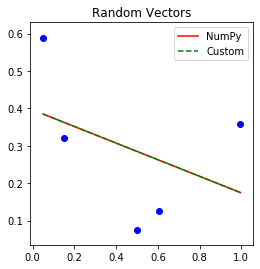

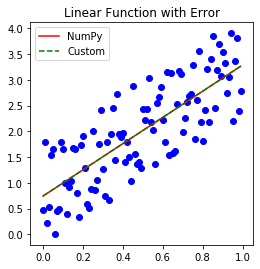

In [25]:
import numpy as np
import matplotlib.pyplot as plt


def lstsq_np(X, Y):
    A = np.vstack([X, np.ones(len(X))]).T
    return np.linalg.lstsq(A, Y, rcond=None)[0]


def lstsq_custom(X, Y):
    n = len(X)
    sx = np.sum(X)
    sy = np.sum(Y)
    sx2 = np.sum(X**2)
    sxy = np.sum(X*Y)
    m = (n * sxy - sx * sy) / (n * sx2 - sx**2)
    c = (sy - m * sx) / n
    return m, c


def solve_and_plot(fun, X, Y, col, lab):
    m, c = fun(X, Y)
    Y2 = m*X+c

    r = Y - Y2
    r_abs = np.abs(r)
    ri_max = np.argmax(r_abs)
    ri_min = np.argmin(r_abs)

    plt.plot(X, Y2, col, label=lab)
    print(f"Slope: {m}, Intercept: {c}")
    print(f"Residuals: {r}")
    print(f"Largest residual error: {r_abs[ri_max]} @ ({X[ri_max]}, {Y[ri_max]})")
    print(f"Smallest residual error: {r_abs[ri_min]} @ ({X[ri_min]}, {Y[ri_min]})\n")


def solve_and_plot_all(X, Y, i):
    plt.figure(figsize=(4,9))
    plt.subplot(2, 1, i)
    plt.scatter(X, Y, c='b')

    print("NumPy solution:")
    solve_and_plot(lstsq_np, X, Y, 'r-', "NumPy")
    print("My custom solution:")
    solve_and_plot(lstsq_custom, X, Y, 'g--', "Custom")
    plt.legend()


# Random Vectors
print("Random Vectors")
X = np.sort(np.random.rand(5))
Y = np.random.rand(5)
solve_and_plot_all(X, Y, 1)
plt.title("Random Vectors")

# Linear Function with Error
print("Linear Function with Error")
X = np.arange(0.0, 1.0, 0.01)
Y = 2.5*X+0.8 + (2.0*np.random.rand(len(X))-1.0)
solve_and_plot_all(X, Y, 2)
plt.title("Linear Function with Error")

plt.show()

# The results of my implementation appear to be identical to NumPy's.
